# Avance 2 — Clustering de departamentos por perfil de Dengue

**Idea:** agrupar los departamentos según su **perfil epidemiológico** (volumen, edad,
sexo, severidad, estacionalidad) para descubrir patrones geográficos.

**Métricas (no supervisado):** método del **codo** (inercia), **Silhouette** y
**Davies-Bouldin**. Se usa **PCA** para visualizar.

## 0. Librerías

In [1]:
import sys; sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Construcción del perfil por departamento

In [2]:
from data import cargar_crudo, normalizar_edad, ORDEN_SEVERIDAD

df = cargar_crudo()
df = normalizar_edad(df)
df['semana'] = pd.to_numeric(df['semana'], errors='coerce')
df['severidad'] = df['enfermedad'].map(ORDEN_SEVERIDAD)
df = df[df['sexo'].isin(['M', 'F'])]
df = df[df['edad_anios'].between(0, 110)]
df = df.dropna(subset=['severidad', 'edad_anios', 'semana', 'departamento'])

perfil = df.groupby('departamento').agg(
    total_casos=('severidad', 'size'),
    edad_media=('edad_anios', 'mean'),
    prop_femenino=('sexo', lambda s: (s == 'F').mean()),
    tasa_con_signos=('severidad', lambda s: (s >= 1).mean()),
    tasa_grave=('severidad', lambda s: (s == 2).mean()),
    semana_pico=('semana', lambda s: s.value_counts().idxmax()),
)
print(perfil.shape)
perfil

(23, 6)


,total_casos,edad_media,prop_femenino,tasa_con_signos,tasa_grave,semana_pico
departamento,,,,,,
AMAZONAS,16805,27.886939,0.527046,0.077715,0.002916,20
ANCASH,37661,33.904579,0.549189,0.080879,0.002257,12
APURIMAC,11,28.727273,0.727273,0.000000,0.000000,21
AREQUIPA,28,32.000000,0.428571,0.107143,0.000000,19
AYACUCHO,9946,30.803934,0.520310,0.038307,0.002212,6
CAJAMARCA,29711,29.245889,0.531419,0.113426,0.001784,20
CALLAO,8138,32.322455,0.537847,0.090194,0.002580,15
CUSCO,15209,32.142338,0.520153,0.051154,0.002433,9
HUANUCO,12119,27.883920,0.507220,0.116099,0.003301,5


In [3]:
# Escalado
X = StandardScaler().fit_transform(perfil.values)
print('Matriz escalada:', X.shape)

Matriz escalada: (23, 6)


## 2. Número óptimo de clústeres (codo + Silhouette)

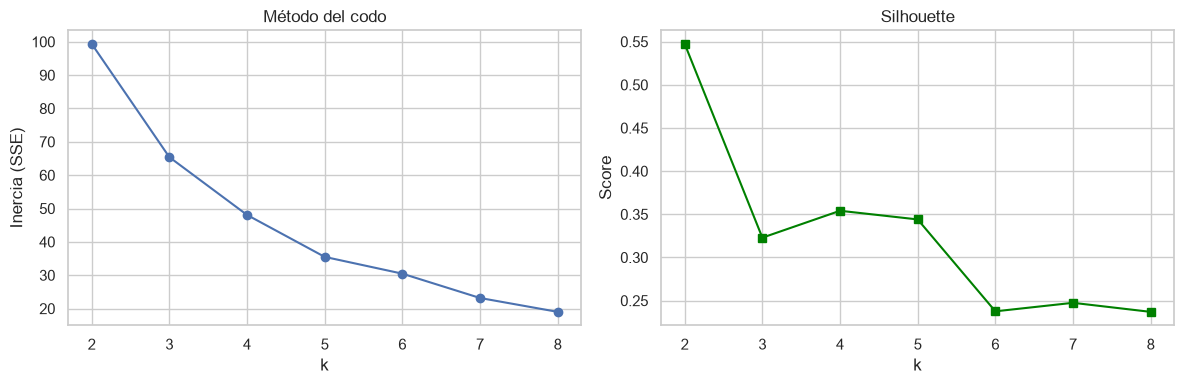

In [4]:
ks = range(2, 9)
inercias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(list(ks), inercias, 'o-'); a1.set_title('Método del codo'); a1.set_xlabel('k'); a1.set_ylabel('Inercia (SSE)')
a2.plot(list(ks), silhouettes, 's-', color='green'); a2.set_title('Silhouette'); a2.set_xlabel('k'); a2.set_ylabel('Score')
plt.tight_layout(); plt.show()

In [5]:
K = list(ks)[int(np.argmax(silhouettes))]
print('k seleccionado por Silhouette:', K)

k seleccionado por Silhouette: 2


## 3. Clustering y métricas

In [6]:
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X)
agg = AgglomerativeClustering(n_clusters=K).fit(X)

for nombre, labels in [('KMeans', km.labels_), ('Jerárquico', agg.labels_)]:
    print(f'{nombre:<12} Silhouette={silhouette_score(X, labels):.3f}  '
          f'Davies-Bouldin={davies_bouldin_score(X, labels):.3f}')

perfil['cluster'] = km.labels_

KMeans       Silhouette=0.547  Davies-Bouldin=0.309
Jerárquico   Silhouette=0.547  Davies-Bouldin=0.309


## 4. Visualización con PCA

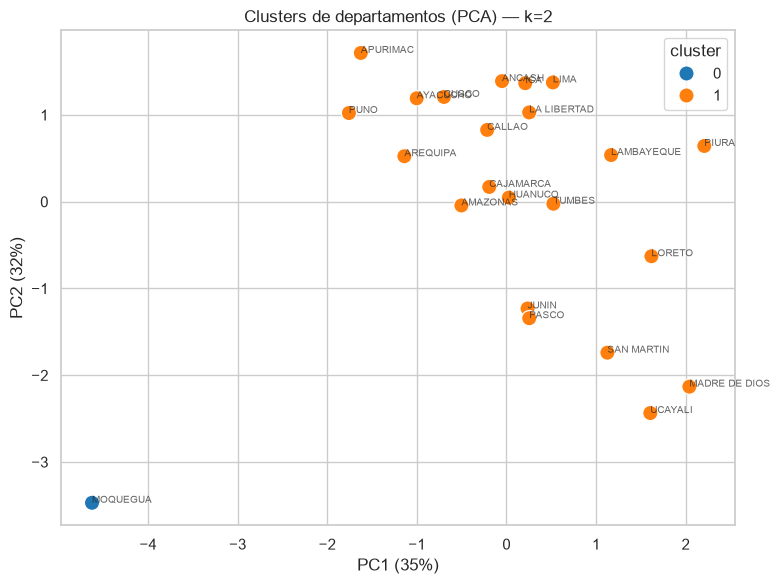

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=km.labels_,
                palette='tab10', s=120)
for i, dep in enumerate(perfil.index):
    plt.annotate(dep, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.7)
plt.title(f'Clusters de departamentos (PCA) — k={K}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
plt.legend(title='cluster'); plt.tight_layout(); plt.show()

In [8]:
# Perfil medio de cada cluster (interpretación)
perfil.groupby('cluster').mean().round(3)

,total_casos,edad_media,prop_femenino,tasa_con_signos,tasa_grave,semana_pico
cluster,,,,,,
0,1.000,19.000,0.000,0.000,0.000,50.000
1,46791.182,30.396,0.536,0.097,0.003,23.455


## 5. ¿Es adecuado el dataset para CLUSTERING?

- Si el **Silhouette** es claramente > 0 (p. ej. > 0.3–0.5) y el **Davies-Bouldin** es bajo →
  existen grupos de departamentos bien diferenciados → dataset adecuado para clustering.
- Interpretar cada cluster con la tabla de perfiles medios (p. ej. "zonas de alta incidencia y
  estacionalidad temprana" vs "zonas de baja incidencia").

> Escribir aquí la conclusión observada.